In [39]:
# Generate the weights list of all possible combinations
import math 

fp_list = ["A","B","C","D"]
weight_list = [0,1,2]
tri_params = []
for a in weight_list:
    for b in weight_list:
        for c in weight_list:
            for d in weight_list:
                    if math.gcd(a,math.gcd(b,math.gcd(c,d))) == 1:
                        tri_params.append([a,b,c,d])



print(len(tri_params))

65


In [50]:
from genra.rax.skl.hybrid import GenRAPredBinaryHybrid
import pandas as pd
slices = [slice(1,732),slice(732,2779), slice(2779,4826), slice(4826, None)]
data = pd.read_csv("../src/data/fingerprint_df.csv")
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score
params = {'hybrid_weights': tri_params}
estimator = GenRAPredBinaryHybrid(metric = 'jaccard', slices = slices, n_neighbors = 13 )

Grid3 = GridSearchCV(estimator=estimator, param_grid=params, n_jobs=-1, cv =5, verbose =3, scoring=['accuracy', 'precision', 'recall', 'roc_auc'], refit = 'accuracy')

Best3 = Grid3.fit(data.iloc[:,2:], data.iloc[:,1])
Best3.best_score_, Best3.best_params_

Fitting 5 folds for each of 65 candidates, totalling 325 fits


(0.7841455044612218, {'hybrid_weights': [0, 2, 0, 1]})

In [72]:
df = pd.DataFrame(Best3.cv_results_)
df
df = df[["param_hybrid_weights", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]]

In [73]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [df["param_hybrid_weights"][i][1] for i in range(0,len(df["param_hybrid_weights"]))]
toxprint_weight = [df["param_hybrid_weights"][i][0] for i in range(0,len(df["param_hybrid_weights"]))]
torsion_weight = [df["param_hybrid_weights"][i][2] for i in range(0,len(df["param_hybrid_weights"]))]
toxcast_weight = [df["param_hybrid_weights"][i][3] for i in range(0,len(df["param_hybrid_weights"]))]

df["morgan"] = [morgan_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
df["toxprint"] = [toxprint_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
df["torsion"] = [torsion_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
df["toxcast"] = [toxcast_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxcast_weight))]

In [77]:
df = df.sort_values("mean_test_accuracy", ascending = False).drop(columns = {"param_hybrid_weights"})

In [89]:
df

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast
14,0.784146,0.784465,0.994521,0.572205,0.666667,0.000000,0.000000,0.333333
33,0.782018,0.781454,0.997260,0.582937,0.200000,0.200000,0.200000,0.400000
32,0.779867,0.783551,0.989003,0.613119,0.250000,0.250000,0.250000,0.250000
59,0.777785,0.780571,0.991781,0.596435,0.142857,0.285714,0.285714,0.285714
39,0.777763,0.783223,0.986301,0.578061,0.400000,0.200000,0.000000,0.400000
...,...,...,...,...,...,...,...,...
7,0.764928,0.776380,0.977968,0.598361,0.333333,0.000000,0.000000,0.666667
63,0.762800,0.778409,0.969673,0.586514,0.285714,0.285714,0.142857,0.285714
55,0.762800,0.775837,0.975152,0.606316,0.200000,0.400000,0.200000,0.200000
38,0.760718,0.774182,0.975228,0.589781,0.500000,0.250000,0.000000,0.250000


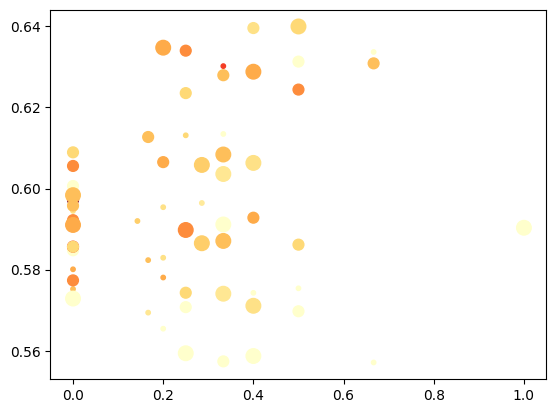

In [88]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice
plt.scatter(x = df["toxprint"], y= df["mean_test_roc_auc"], c= df["morgan"], cmap = "YlOrRd", s = [i*50+10 for i in toxprint_weight])
# title = "Rec(toxc-c_mor_s_toxp)"
# plt.title(title)
# plt.savefig(f"../references/tp_tor_mor/91test{title}percents_scatter.png")
plt.show()

# Data Analysis for Long-Form Results

In [17]:
import pandas as pd
import matplotlib

score_df = pd.read_csv("../references/tp_tor_mor/prelim_results+tc_df.csv")
score_df["weights"] = [ [int(score_df["weights"][i][1]), int(score_df["weights"][i][4]), int(score_df["weights"][i][7]), int(score_df["weights"][i][10])] for i in range(0, len(score_df["weights"]))]
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414


In [32]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [score_df["weights"][i][1] for i in range(0,len(score_df["weights"]))]
toxprint_weight = [score_df["weights"][i][0] for i in range(0,len(score_df["weights"]))]
torsion_weight = [score_df["weights"][i][2] for i in range(0,len(score_df["weights"]))]
toxcast_weight = [score_df["weights"][i][3] for i in range(0,len(score_df["weights"]))]

score_df["morgan"] = [morgan_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(morgan_weight))]
score_df["toxprint"] = [toxprint_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxprint_weight))]
score_df["torsion"] = [torsion_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(torsion_weight))]
score_df["toxcast"] = [toxcast_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxcast_weight))]

In [33]:
#Check the DataFrame
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177,0.0,0.0,0.000000,1.000000
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365,0.0,0.0,1.000000,0.000000
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177,0.0,0.0,0.500000,0.500000
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464,0.0,0.0,0.333333,0.666667
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414,0.0,0.0,0.666667,0.333333


In [34]:
#Obtain best combination for accuracy
score_df.loc[score_df["accuracy"]==max(score_df["accuracy"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
22,"[1, 0, 1, 0]",344,16,90,18,0.769231,0.792627,0.950276,0.0,0.5,0.5,0.0


In [35]:
#Obtain best combination for precision
score_df.loc[score_df["precision"]==max(score_df["precision"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
50,"[2, 0, 2, 1]",341,17,89,21,0.764957,0.793023,0.941989,0.0,0.4,0.4,0.2


In [36]:
#Obtain best combination for recall
score_df.loc[score_df["recall"]==max(score_df["recall"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
19,"[1, 0, 0, 0]",345,11,95,17,0.760684,0.784091,0.953039,0.0,1.0,0.0,0.0


In [37]:
#Obtain best combination for not getting false positives
score_df.loc[score_df["FP"]==min(score_df["FP"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.0,0.0,1.0
27,"[1, 0, 2, 2]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.2,0.4,0.4


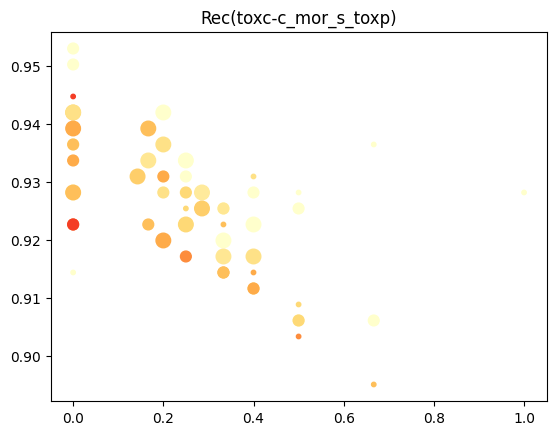

In [38]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice
plt.scatter(x = score_df["toxcast"], y= score_df["recall"], c= score_df["morgan"], cmap = "YlOrRd", s = [i*50+10 for i in toxprint_weight])
title = "Rec(toxc-c_mor_s_toxp)"
plt.title(title)
# plt.savefig(f"../references/tp_tor_mor/91test{title}percents_scatter.png")
plt.show()